In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib widget

In [8]:
# Define the publication style
pub_style = {
    # FONT CONFIGURATION
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,              # Base font size (usually 7-9pt for captions/axis)
    'axes.labelsize': 9,         # Axis labels slightly larger
    'axes.titlesize': 10,        # Title slightly larger
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,

    # LINE AND MARKER CONFIGURATION
    'lines.linewidth': 1.5,      # Thicker lines for visibility
    'lines.markersize': 5,
    'axes.linewidth': 1,         # Thicker axes frame (spines)

    # LAYOUT CONFIGURATION
    'xtick.direction': 'in',     # Ticks point inside the plot (standard scientific style)
    'ytick.direction': 'in',
    'xtick.major.size': 4,       # Length of major ticks
    'ytick.major.size': 4,
    'xtick.bottom': True,
    'ytick.left': True,
    'figure.constrained_layout.use': True,

    # SAVE CONFIGURATION
    'savefig.dpi': 300,          # High res for raster elements (if any)
    'savefig.bbox': 'tight',     # Prevent cutting off labels
    'savefig.format': 'pdf',     # Default save format
    'pdf.fonttype': 42,          # Embed fonts as TrueType (editable in Illustrator)
    'ps.fonttype': 42,
    
    # FIGURE CONFIGURATION
    'figure.figsize': (3.5, 2.5), # Default to single-column width (approx 89mm)
    'figure.dpi': 150            # Screen resolution (makes plots look nice in notebook)
}

# Apply the settings
plt.rcParams.update(pub_style)

# Optional: Enable LaTeX for math formatting if you have a TeX distribution installed
# plt.rcParams['text.usetex'] = True 

print("Publication plotting defaults applied.")

Publication plotting defaults applied.


In [3]:
spec_path = "../data/spectrometer_bin_response.txt"

with open(spec_path, "r") as f:
    print(f.readline())

# dbin, fbin, pwr, zm0, zm1, zm2, zm3, zm4, zm5, zm6, zm7, zm8, zm9, zm10, zm11, zm12, zm13, zm14, zm15, zm16, zm17, zm18, zm19, zm20, zm21, zm22, zm23, zm24, zm25, zm26, zm27, zm28, zm29, zm30, zm31, zm32, zm33, zm34, zm35, zm36, zm37, zm38, zm39, zm40, zm41, zm42, zm43, zm44, zm45, zm46, zm47, zm48, zm49, zm50, zm51, zm52, zm53, zm54, zm55, zm56, zm57, zm58, zm59, zm60, zm61, zm62, zm63



In [4]:
spec = np.loadtxt(spec_path, skiprows=1)
print(spec.shape)
dbin = spec[:, 0]
fbin = spec[:, 1] / 1e3 # kHz
pwr = spec[:, 2]
pwr /= pwr.sum()  # normalized power - to use for weighted avg
zoom = spec[:, 3:]
zoom /= zoom.sum(axis=0, keepdims=True)

(10001, 67)


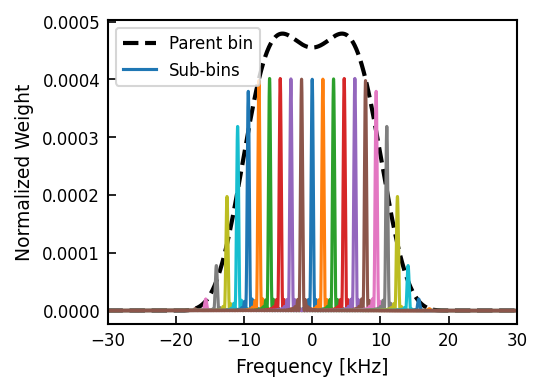

In [21]:
#plt.figure(figsize=(3.5, 2.5))
plt.figure()
plt.plot(fbin, pwr, c="k", label="Parent bin", ls="--", lw=2)  # parent bin
plt.plot(fbin, zoom[:, 0]/64, ls="-", label="Sub-bins")
for i in range(1, 16):
    plt.plot(fbin, zoom[:, 4*i]/64, ls="-")
plt.legend(loc="upper left")
plt.xlim(-30, 30)
plt.xlabel("Frequency [kHz]")
plt.ylabel("Normalized Weight")
plt.savefig("spec_response.pdf", bbox_inches="tight")
plt.show()